Llegamos a ese punto donde las CPUs ya no dan abasto: cuando los datasets crecen y los modelos se vuelven más profundos, dar el salto a una **GPU (Graphics Processing Unit)** deja de ser un lujo y se convierte en una necesidad computacional.

Aquí te dejo una síntesis clara y al grano de las diferencias fundamentales:

---

### CPU (Central Processing Unit)

* **Propósito General:** Diseñada para manejar la lógica del sistema operativo, abrir y cerrar programas, lectura y escritura en disco, y tareas de control.
* **Procesamiento en Serie:** Ejecuta instrucciones complejas paso a paso de forma secuencial.
* **Arquitectura:** Cuenta con pocos núcleos (4, 8, 16 o 64), pero extremadamente rápidos y con baja latencia por ciclo de reloj.

---

###  GPU (Graphics Processing Unit)

* **Especializada en Paralelismo Masivo:** Diseñada originalmente para gráficos, pero perfecta para el Deep Learning, donde prácticamente todo se reduce a **multiplicación de matrices y álgebra lineal**.
* **Arquitectura SIMD (Single Instruction, Multiple Data):** En lugar de pocos núcleos rápidos, contiene miles de núcleos más pequeños y sencillos que ejecutan la misma operación matemática simultáneamente sobre distintos bloques de datos.
* **División de tareas:** Parte una matriz gigante en miles de micro-bloques, calcula los productos en paralelo en cada núcleo y luego reúne el resultado en un tiempo fraccionario comparado con una CPU.

---

###  El "coste" de usar una GPU: Memoria y Transferencia

Trabajar con GPUs no es completamente transparente en el código; implica gestionar el ciclo de vida del dato:

1. **Drivers y librerías especializadas:** Requiere capas de software como NVIDIA CUDA y cuDNN.
2. **Transferencia de tensores:** La GPU tiene su propia memoria dedicada (VRAM). Todo dato o peso debe transferirse explícitamente desde la memoria RAM del sistema a la VRAM (`tensor.to(device)`) antes de operar, cuidando los cuellos de botella en el bus PCIe.

La diferencia estructural entre una **CPU** y una **GPU** se entiende observando cómo distribuyen el espacio físico del silicio entre tres componentes clave: la **ALU (Arithmetic Logic Unit)**, la **Unidad de Control (Control Unit)** y la **Memoria Caché**.

---

### 1. La ALU (Arithmetic Logic Unit / Unidad Aritmético-Lógica)

La ALU es el circuito integrado encargado de ejecutar operaciones matemáticas (sumas, multiplicaciones, operaciones lógicas AND/OR, comparaciones).

* **En la CPU:** Tiene **pocas ALUs**, pero son extremadamente complejas, pesadas y rápidas. Están diseñadas para resolver operaciones matemáticas complejas con enteros o coma flotante de alta precisión en un solo ciclo de reloj o con muy pocos ciclos, minimizando la latencia de una instrucción individual.
* **En la GPU:** Sacrifica la complejidad individual para incluir **miles de ALUs más simples** (CUDA Cores en NVIDIA o Stream Processors en AMD). Cada ALU individual es más lenta y menos versátil que la de una CPU, pero como operan en paralelo bajo el modelo SIMD (*Single Instruction, Multiple Data*), pueden calcular miles de multiplicaciones y sumas escalares simultáneamente. Esto es exactamente lo que requiere una multiplicación matricial en Deep Learning.

---

### 2. La Unidad de Control (*Control Unit*) y la Lógica de Predicción

* **En la CPU (Optimización de latencia):** Una gran parte del chip se destina a circuitería de control avanzada:
* **Branch Prediction (Predicción de saltos):** Adivina qué rama de un `if/else` se ejecutará para no detener el procesador.
* **Out-of-Order Execution (Ejecución fuera de orden):** Reorganiza las instrucciones al vuelo para mantener las ALUs ocupadas mientras esperan datos.


* **En la GPU (Optimización de rendimiento / *Throughput*):** La unidad de control es mínima y compartida entre grupos de ALUs (*Warps*). No necesita lógica compleja de predicción de saltos porque asume que todos los núcleos están ejecutando la misma operación exacta sobre diferentes fragmentos de una matriz.

---

### 3. La Jerarquía de Memoria Caché (L1, L2, L3)

* **En la CPU (Caché grande y profunda):**
* La CPU dedica un porcentaje enorme de su silicio a memorias caché ultrarrápidas y de gran capacidad (**L1, L2 y una enorme L3 compartida**).
* **Objetivo:** Evitar a toda costa el acceso a la RAM principal, ya que una parada (*stall*) por esperar un dato arruina la velocidad del hilo de ejecución en serie.


* **En la GPU (Caché pequeña y ancho de banda masivo):**
* Tiene memorias intermedias pequeñas (L1/Shared Memory y L2 compartida), pero **no intenta almacenar grandes volúmenes de datos en caché** para evitar la latencia.
* **Objetivo:** Oculta la latencia mediante paralelismo masivo. Si un grupo de ALUs está esperando datos que vienen de la VRAM (HBM o GDDR), la GPU simplemente conmuta instantáneamente a otro grupo de miles de ALUs listas para calcular.
* Por esto, la GPU compensa el menor tamaño de caché con un **ancho de banda de memoria masivo** (cientos o miles de GB/s frente a las decenas de GB/s de la RAM de CPU).



---

###  Comparativa de Distribución del Silicio

| Componente | CPU (Optimizado para Latencia) | GPU (Optimizado para *Throughput*) |
| --- | --- | --- |
| **ALUs** | Pocas (~4 a 64), muy rápidas y complejas. | Miles (miles de *cores*), simples y paralelas. |
| **Caché** | Enorme (L1, L2, L3) para retener datos y evitar esperar a la RAM. | Pequeña, diseñada solo para intercambios locales rápidos. |
| **Unidad de Control** | Muy grande y compleja (predicción de saltos, ejecución fuera de orden). | Muy compacta y compartida entre grandes bloques de ALUs. |
| **Filosofía** | Terminar una tarea secuencial lo antes posible (*Low Latency*). | Procesar la mayor cantidad de datos por segundo (*High Throughput*). |

In [ ]:
## Por lo tanto se usa la CPU y la GPU en el entrenamiendo del deep Learning

In [ ]:
# Importar librerías
import time
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

## Seleccionar el dispositivo de procesamiento

In [ ]:
## Nota: Para ejecutar modelos en una GPU debes seleccionar en el menú:
#   -> Entorno de ejecución (Runtime)
#     -> Cambiar tipo de entorno de ejecución
#       -> Acelerador de hardware
#         -> GPU

In [ ]:
# Crear una variable para acceder a la GPU - para prevenir errores si no estamos usando la GPU
device = torch.device('cuda:0' if torch.cuda.is_available() else 'cpu')
print(device)

cpu


## Construir un modelo simple

In [ ]:
# Este modelo está construido en la CPU (solo son Lineal Layers separadas por una no linealidad)
net = nn.Sequential(
    nn.Linear(20, 100),
    nn.ReLU(),
    nn.Linear(100, 500),
    nn.ReLU(),
    nn.Linear(500, 30),
    nn.ReLU(),
    nn.Linear(30, 2),
)

Este modelo de funciones lineales esta en la CPU porque no le hemos dicho a pytorch que lo cambie a la GPU

## Generar algunos datos

In [ ]:
# Los datos también se crean en la CPU
data   = torch.randn((1000, 20))  # muestras X características
labels = torch.randint(low=0, high=2, size=(1, 1000))

## Enviar el modelo y los datos a la GPU

In [ ]:
# Ahora enviar el modelo a la GPU
net.to(device)

# Y enviar los datos allí
data   = data.to(device)
labels = labels.to(device)

In [ ]:
data

tensor([[ 0.2521, -1.5399, -0.2407,  ..., -1.0807,  0.0054,  0.3955],
        [ 0.4576,  1.3351,  0.6966,  ..., -0.6629,  1.1510,  1.7905],
        [ 1.0134,  1.4303, -0.8686,  ..., -0.6622,  0.8394,  0.9867],
        ...,
        [ 0.0342, -0.1559, -1.7528,  ...,  2.5738, -0.9631, -0.0971],
        [ 0.5907,  1.4731,  0.6123,  ...,  0.5242, -0.8779, -0.2165],
        [-0.1648, -2.2269, -0.0930,  ..., -0.2521,  0.9072,  0.5881]])

In [ ]:
# También puedes crear datos directamente en la GPU
dataG = torch.randn((1000, 20), device=device) # puedes definirlos directo a la GPU
dataC = torch.randn((1000, 20), device='cpu')  # puedes definirlos directo a la CPU

print(data.device)
print(dataG.device)
print(dataC.device)

cpu
cpu
cpu


La variable .to es aplicable solo a objetos de Pytorch no funcionara con array de numpy o un objeto de python

## Obteniendo resultados del modelo

In [ ]:
output = net(data)

In [ ]:
  output.device

device(type='cpu')

Si ejecutamos el dataG nos dara un error porque el modelo vive en la GPU pero los datos en la CPU puedes hacer algo como esto para enviarlos net(dataC.to(device))

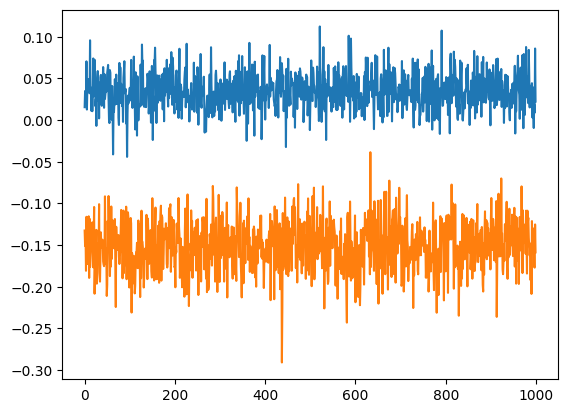

In [ ]:
# Intentar graficar los datos # metodo item es especialmente para escalares
plt.plot(output.detach());

# plt.plot(output.detach().cpu());

Al igual que con plt no va a funcionar si los datos viven en la CPU o GPU

## Experimento: Tiempo de cómputo

In [ ]:
# Sincronizar la GPU y la CPU (útil para medir tiempos de cómputo; no es una buena idea para aplicaciones en producción)
torch.cuda.synchronize()

# Iniciar el cronómetro
starttime = time.process_time()

# Mover, ejecutar, recuperar
device = 'cuda:0'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# Detener el cronómetro
GPUtime = 1000 * (time.process_time() - starttime)

AssertionError: Torch not compiled with CUDA enabled

In [ ]:
# Iniciar el cronómetro
starttime = time.process_time()

# Mover, ejecutar, recuperar
device = 'cpu'
net.to(device)
data   = data.to(device)
labels = labels.to(device)
output = net(data).detach().cpu()

# Detener el cronómetro
CPUtime = 1000 * (time.process_time() - starttime)

In [ ]:
# Tiempo en ms
print(f'Tiempo en CPU: {CPUtime:.3f} milisegundos')
print(f'Tiempo en GPU: {GPUtime:.3f} ms.')

Tiempo en CPU: 10.412 milisegundos


NameError: name 'GPUtime' is not defined

In [ ]:
# ¿Quizás "enviarlo" a la CPU genera demasiada sobrecarga (overhead)?

In [ ]:

# recreate network and data
net  = nn.Sequential(nn.Linear(20,100),nn.ReLU(),nn.Linear(100,500),nn.ReLU(),nn.Linear(500,30),nn.ReLU(),nn.Linear(30,2))
data = torch.randn((1000,20))

# rerun the experiment
starttime = time.process_time()
output    = net(data).detach()
CPUtime2  = 1000*(time.process_time() - starttime)

# report the results
print(f'CPU  time: {CPUtime:.3f} ms')
print(f'CPU2 time: {CPUtime2:.3f} ms')
# print(f'GPU  time: {GPUtime:.3f} ms')

CPU  time: 10.412 ms
CPU2 time: 5.871 ms
